# AI Thực Chiến - Round 2 API Notebook

**How it is organised**

| Part | What | When |
|---|---|---|
| 1 | Setup (paste key) | every time |
| 2 | **Model catalog** (every model from the docs) | look things up |
| 3 | Client + one-line helpers (`gen_text`, `gen_image`, `gen_video`, ...) | run once |
| 4 | **Quick generate** - edit a prompt, run the cell | competition day |
| 5 | Smoke tests - checks every endpoint works | before competition |

**Everything you generate is saved automatically** to `outputs/<type>/<timestamp>_<prompt>.<ext>` and logged to `outputs/history.jsonl` (prompt, model, file, cost).

**Costs to watch:** video is billed per second the moment the job starts. Search grounding costs about $0.03 per query.

## Part 1 - Setup

In [2]:
# Only dependency besides the standard library:  %pip install requests
import base64, datetime, getpass, json, mimetypes, os, re, time, unicodedata
from pathlib import Path

import requests

try:
    from IPython.display import Audio, Image, Markdown, Video, display
    IN_JUPYTER = True
except ImportError:
    IN_JUPYTER = False

BASE_URL = "https://api.thucchien.ai"
OUT_DIR = Path("outputs")          # everything generated is saved here
OUT_DIR.mkdir(exist_ok=True)

# Key: env var THUCCHIEN_API_KEY, or you get asked (never written to disk)
API_KEY = os.environ.get("THUCCHIEN_API_KEY") or getpass.getpass("Paste your API key: ")

## Part 2 - Model catalog (everything listed in the docs)

**Text - Gemini** &nbsp;(`/chat/completions`)

| Model ID | Notes |
|---|---|
| `gemini-3.8-flash` | Flash |
| `gemini-3.7-flash` | Flash |
| `gemini-3.6-flash` | Flash |
| `gemini-3.5-flash` | Flash |
| `gemini-3.5-flash-lite` | Flash-Lite (cheaper/faster) |
| `gemini-3.1-flash-lite` | Flash-Lite (cheaper/faster) |
| `gemini-3.1-pro-preview` | Pro (preview) |
| `gemini-2.5-pro` | Pro, older generation |
| `gemini-2.5-flash` | Flash, older generation |

**Text - OpenAI (all are reasoning models)** &nbsp;(`/chat/completions or /responses`)

| Model ID | Notes |
|---|---|
| `gpt-6.1-sol` | reasoning_effort: low/medium/high/xhigh/max (no 'none') |
| `gpt-6-astra` | reasoning_effort: low/medium/high/xhigh/max (no 'none') |
| `gpt-6-sol` | reasoning_effort: none/low/medium/high/xhigh/max |
| `gpt-6-luna` | reasoning_effort: none/low/medium/high/xhigh/max |
| `gpt-5.6-sol` | reasoning_effort: none/low/medium/high/xhigh/max |
| `gpt-5.6-terra` | reasoning_effort: none/low/medium/high/xhigh/max |
| `gpt-5.6-luna` | reasoning_effort: none/low/medium/high/xhigh/max |
| `o3` | reasoning_effort: low/medium/high only |
| `o4-mini` | reasoning_effort: low/medium/high only |

**Text - DeepSeek** &nbsp;(`/chat/completions`)

| Model ID | Notes |
|---|---|
| `deepseek-flash` | Fast + cheap. Thinking ON by default; turn off with thinking={'type':'disabled'} |
| `deepseek-v4-pro` | Stronger, ~4x the price of flash |

**Image - Nano Banana (Gemini Image)** &nbsp;(`/images/generations or /chat/completions`)

| Model ID | Notes |
|---|---|
| `nano-banana-2` | = gemini-3.1-flash-image |
| `nano-banana-2-lite` | = gemini-3.1-flash-lite-image. Cheapest + fastest |
| `nano-banana-pro` | = gemini-3-pro-image. Highest quality |
| `nano-banana` | = gemini-2.5-flash-image. Google ended support 02/10/2026 -> avoid |
| `gemini-3.1-flash-image` | original ID of nano-banana-2 |
| `gemini-3.1-flash-lite-image` | original ID of nano-banana-2-lite |
| `gemini-3-pro-image` | original ID of nano-banana-pro |
| `gemini-2.5-flash-image` | original ID of nano-banana (retired) |

**Image - OpenAI** &nbsp;(`/images/generations`)

| Model ID | Notes |
|---|---|
| `gpt-image-2.5-flare` | size + quality params; 1024x1024 'low' ~ $0.006 |
| `gpt-image-2.5-sunburst` | size + quality params |

**Video - Veo 3.1** &nbsp;(`/v1/videos`)

| Model ID | Notes |
|---|---|
| `veo-3.1-generate-001` | Best quality. $0.40 / second |
| `veo-3.1-fast-generate-001` | Faster/cheaper. $0.10/s (720p), $0.12/s (1080p) |
| `veo-3.1-lite-generate-001` | Cheapest. $0.05/s (720p), $0.08/s (1080p) |

**Text-to-speech** &nbsp;(`/audio/speech`)

| Model ID | Notes |
|---|---|
| `gemini-3.1-flash-tts-preview` | Gemini voices |
| `gemini-2.5-flash-preview-tts` | Gemini voices |
| `gemini-2.5-pro-preview-tts` | Gemini voices |
| `gpt-4o-mini-tts` | OpenAI voices (alloy, echo, fable, onyx, nova, shimmer...) NOT Gemini voices |

**Speech-to-text** &nbsp;(`/audio/transcriptions`)

| Model ID | Notes |
|---|---|
| `gemini-3.5-transcribe-preview` | Vietnamese supported |
| `gpt-4o-transcribe` | OpenAI |
| `gpt-4o-mini-transcribe` | OpenAI |
| `gpt-transcribe` | OpenAI. MUST send response_format='json' (client does it for you) |
| `whisper-1` | OpenAI |

**Embeddings** &nbsp;(`/embeddings`)

| Model ID | Notes |
|---|---|
| `gemini-embedding-001` | 3072 dims, multilingual (VI ok), $0.15/1M tokens |
| `gemini-embedding-2` | 3072 dims, multilingual (VI ok), $0.20/1M. ONE text per request! |
| `text-multilingual-embedding-002` | 768 dims, multilingual (VI ok), $0.10/1M |
| `text-embedding-005` | 768 dims, mostly English, $0.10/1M |
| `text-embedding-3-small` | OpenAI, 1536 dims, $0.02/1M |
| `text-embedding-3-large` | OpenAI, 3072 dims, $0.13/1M |

**Moderation** &nbsp;(`/moderations`)

| Model ID | Notes |
|---|---|
| `omni-moderation-latest` | OpenAI content moderation, free |

**Gemini TTS voices (30):** Zephyr, Puck, Charon, Kore, Fenrir, Leda, Orus, Aoede, Callirrhoe, Autonoe, Enceladus, Iapetus, Umbriel, Algieba, Despina, Erinome, Algenib, Rasalgethi, Laomedeia, Achernar, Alnilam, Schedar, Gacrux, Pulcherrima, Achird, Zubenelgenubi, Vindemiatrix, Sadachbia, Sadaltager, Sulafat

**OpenAI TTS voices:** alloy, echo, fable, onyx, nova, shimmer

**Nano Banana aspect ratios:** `1:1` (default), `3:4`, `4:3`, `16:9`, `9:16`  (`n` must be 1; `size` is ignored)

**gpt-image sizes:** `1024x1024`, `1536x1024`, `1024x1536`; quality: `low` / `medium` / `high`

**Veo:** seconds `"4"`, `"6"`, `"8"` (default 8); size `1280x720` (default), `1920x1080`, `720x1280`, `1080x1920`; optional start image (image-to-video)

**Web search:** Gemini -> `tools=[{"googleSearch": {}}]` on `/chat/completions`. OpenAI (`gpt-5.6-*`, `gpt-6*`, `o3`, `o4-mini`) -> `/responses` with `tools=[{"type": "web_search"}]`. DeepSeek: not supported.

**Rules of thumb from the docs**
- OpenAI `gpt-6*`: use `max_completion_tokens` (not `max_tokens`) and never set it tiny - reasoning tokens eat it and the answer comes back empty. `temperature`/`top_p` are ignored.
- DeepSeek: no images/audio/search input. Old names `deepseek-v4-flash` are blocked (403), use `deepseek-flash`.
- Vectors from different embedding models are not comparable; use the same model for indexing and querying.
- Budget, RPM and TPM are per **team**, shared by all team keys.

> The docs pages for *pricing*, *introduction*, and the image/TTS/STT guides could not be read when this was built, so the catalog may miss models or prices from those pages. Run the `check_catalog()` cell below to compare against what your key can actually call.

In [2]:
CATALOG = {
    "text_gemini": [
        ('gemini-3.8-flash', 'Flash'),
        ('gemini-3.7-flash', 'Flash'),
        ('gemini-3.6-flash', 'Flash'),
        ('gemini-3.5-flash', 'Flash'),
        ('gemini-3.5-flash-lite', 'Flash-Lite (cheaper/faster)'),
        ('gemini-3.1-flash-lite', 'Flash-Lite (cheaper/faster)'),
        ('gemini-3.1-pro-preview', 'Pro (preview)'),
        ('gemini-2.5-pro', 'Pro, older generation'),
        ('gemini-2.5-flash', 'Flash, older generation'),
    ],
    "text_openai": [
        ('gpt-6.1-sol', "reasoning_effort: low/medium/high/xhigh/max (no 'none')"),
        ('gpt-6-astra', "reasoning_effort: low/medium/high/xhigh/max (no 'none')"),
        ('gpt-6-sol', 'reasoning_effort: none/low/medium/high/xhigh/max'),
        ('gpt-6-luna', 'reasoning_effort: none/low/medium/high/xhigh/max'),
        ('gpt-5.6-sol', 'reasoning_effort: none/low/medium/high/xhigh/max'),
        ('gpt-5.6-terra', 'reasoning_effort: none/low/medium/high/xhigh/max'),
        ('gpt-5.6-luna', 'reasoning_effort: none/low/medium/high/xhigh/max'),
        ('o3', 'reasoning_effort: low/medium/high only'),
        ('o4-mini', 'reasoning_effort: low/medium/high only'),
    ],
    "text_deepseek": [
        ('deepseek-flash', "Fast + cheap. Thinking ON by default; turn off with thinking={'type':'disabled'}"),
        ('deepseek-v4-pro', 'Stronger, ~4x the price of flash'),
    ],
    "image_nano_banana": [
        ('nano-banana-2', '= gemini-3.1-flash-image'),
        ('nano-banana-2-lite', '= gemini-3.1-flash-lite-image. Cheapest + fastest'),
        ('nano-banana-pro', '= gemini-3-pro-image. Highest quality'),
        ('nano-banana', '= gemini-2.5-flash-image. Google ended support 02/10/2026 -> avoid'),
        ('gemini-3.1-flash-image', 'original ID of nano-banana-2'),
        ('gemini-3.1-flash-lite-image', 'original ID of nano-banana-2-lite'),
        ('gemini-3-pro-image', 'original ID of nano-banana-pro'),
        ('gemini-2.5-flash-image', 'original ID of nano-banana (retired)'),
    ],
    "image_openai": [
        ('gpt-image-2.5-flare', "size + quality params; 1024x1024 'low' ~ $0.006"),
        ('gpt-image-2.5-sunburst', 'size + quality params'),
    ],
    "video": [
        ('veo-3.1-generate-001', 'Best quality. $0.40 / second'),
        ('veo-3.1-fast-generate-001', 'Faster/cheaper. $0.10/s (720p), $0.12/s (1080p)'),
        ('veo-3.1-lite-generate-001', 'Cheapest. $0.05/s (720p), $0.08/s (1080p)'),
    ],
    "tts": [
        ('gemini-3.1-flash-tts-preview', 'Gemini voices'),
        ('gemini-2.5-flash-preview-tts', 'Gemini voices'),
        ('gemini-2.5-pro-preview-tts', 'Gemini voices'),
        ('gpt-4o-mini-tts', 'OpenAI voices (alloy, echo, fable, onyx, nova, shimmer...) NOT Gemini voices'),
    ],
    "stt": [
        ('gemini-3.5-transcribe-preview', 'Vietnamese supported'),
        ('gpt-4o-transcribe', 'OpenAI'),
        ('gpt-4o-mini-transcribe', 'OpenAI'),
        ('gpt-transcribe', "OpenAI. MUST send response_format='json' (client does it for you)"),
        ('whisper-1', 'OpenAI'),
    ],
    "embedding": [
        ('gemini-embedding-001', '3072 dims, multilingual (VI ok), $0.15/1M tokens'),
        ('gemini-embedding-2', '3072 dims, multilingual (VI ok), $0.20/1M. ONE text per request!'),
        ('text-multilingual-embedding-002', '768 dims, multilingual (VI ok), $0.10/1M'),
        ('text-embedding-005', '768 dims, mostly English, $0.10/1M'),
        ('text-embedding-3-small', 'OpenAI, 1536 dims, $0.02/1M'),
        ('text-embedding-3-large', 'OpenAI, 3072 dims, $0.13/1M'),
    ],
    "moderation": [
        ('omni-moderation-latest', 'OpenAI content moderation, free'),
    ],
}

GEMINI_VOICES = ['Zephyr', 'Puck', 'Charon', 'Kore', 'Fenrir', 'Leda', 'Orus', 'Aoede', 'Callirrhoe', 'Autonoe', 'Enceladus', 'Iapetus', 'Umbriel', 'Algieba', 'Despina', 'Erinome', 'Algenib', 'Rasalgethi', 'Laomedeia', 'Achernar', 'Alnilam', 'Schedar', 'Gacrux', 'Pulcherrima', 'Achird', 'Zubenelgenubi', 'Vindemiatrix', 'Sadachbia', 'Sadaltager', 'Sulafat']
OPENAI_VOICES = ["alloy", "echo", "fable", "onyx", "nova", "shimmer"]


def show_models(category=None):
    """Print the catalog. show_models() = everything, show_models('video') = one category."""
    for key, items in CATALOG.items():
        if category and key != category:
            continue
        print(f"\n[{key}]")
        for model, note in items:
            print(f"  {model:<34} {note}")
    if category is None:
        print("\nCategories:", ", ".join(CATALOG))

### Default models used by the helpers - change them here

In [3]:
DEFAULT = {
    "text":       "gemini-3.5-flash-lite",       # try: gemini-3.1-pro-preview, gpt-6-luna, deepseek-flash
    "search":     "gemini-3.5-flash-lite",       # Gemini -> googleSearch, gpt-* -> /responses web_search
    "image":      "nano-banana-2-lite",          # try: nano-banana-2, nano-banana-pro, gpt-image-2.5-flare
    "tts":        "gemini-2.5-flash-preview-tts",
    "stt":        "gemini-3.5-transcribe-preview",
    "embedding":  "text-multilingual-embedding-002",
    "moderation": "omni-moderation-latest",
    "video":      "veo-3.1-lite-generate-001",   # cheapest. try: veo-3.1-fast-generate-001, veo-3.1-generate-001
}

## Part 3 - Client and helpers

`ThucChienClient` talks to every endpoint (auth, auto-retry on 429/5xx, clear errors, cost tracking, auto-saving).
The `gen_*` functions below it are the short versions you will actually type.

In [4]:
class APIError(RuntimeError):
    """Any non-2xx response. Message contains the HTTP status and body."""


def _is_openai_chat(model):          # gpt-5.6-*, gpt-6*, o3, o4-mini
    return model.startswith(("gpt-5", "gpt-6", "o3", "o4"))


def _slug(text, n=40):
    text = (text or "").replace("đ", "d").replace("Đ", "D")
    text = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode()
    return re.sub(r"[^a-zA-Z0-9]+", "-", text.lower()).strip("-")[:n] or "output"


# Veo price per generated second (USD), from the docs
VEO_PRICE = {
    "veo-3.1-generate-001":      {"720p": 0.40, "1080p": 0.40},
    "veo-3.1-fast-generate-001": {"720p": 0.10, "1080p": 0.12},
    "veo-3.1-lite-generate-001": {"720p": 0.05, "1080p": 0.08},
}

def video_cost(model, seconds=8, size="1280x720"):
    res = "1080p" if max(int(x) for x in size.split("x")) >= 1920 else "720p"
    return VEO_PRICE.get(model, {}).get(res, 0) * int(seconds)


class ThucChienClient:
    def __init__(self, api_key, base_url=BASE_URL, timeout=180, max_retries=3, out_dir=OUT_DIR):
        self.base_url = base_url.rstrip("/")
        self.timeout = timeout
        self.max_retries = max_retries
        self.out_dir = Path(out_dir)
        self.out_dir.mkdir(parents=True, exist_ok=True)
        self.session = requests.Session()
        self.session.headers["Authorization"] = f"Bearer {api_key}"
        self.total_cost = 0.0      # running USD total of calls made by this client
        self.last_cost = None      # cost of the latest call

    # ---------------------------------------------------- plumbing
    def _request(self, method, path, *, json_body=None, data=None, files=None,
                 params=None, stream=False, timeout=None):
        url = f"{self.base_url}{path}"
        for attempt in range(self.max_retries + 1):
            resp = self.session.request(method, url, json=json_body, data=data, files=files,
                                        params=params, stream=stream, timeout=timeout or self.timeout)
            if resp.status_code in (429, 500, 502, 503, 504) and attempt < self.max_retries:
                try:
                    wait = float(resp.headers.get("retry-after", ""))
                except ValueError:
                    wait = 2 ** (attempt + 1)
                print(f"  [retry {attempt + 1}/{self.max_retries}] HTTP {resp.status_code} on {path}, waiting {wait:.0f}s")
                time.sleep(wait)
                continue
            break
        cost = resp.headers.get("x-litellm-response-cost")
        if cost:
            try:
                self.last_cost = float(cost)
                self.total_cost += self.last_cost
            except ValueError:
                pass
        if not resp.ok:
            raise APIError(f"{method} {path} -> HTTP {resp.status_code}: {resp.text[:1500]}")
        return resp

    def _post_json(self, path, body):
        return self._request("POST", path, json_body=body).json()

    def _auto_path(self, kind, prompt, ext):
        stamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
        folder = self.out_dir / kind
        folder.mkdir(parents=True, exist_ok=True)
        return folder / f"{stamp}_{_slug(prompt)}.{ext}"

    def _save(self, content, kind, prompt, ext, filename=None):
        """Save bytes. filename=None -> outputs/<kind>/<timestamp>_<prompt-slug>.<ext>"""
        if filename is None:
            path = self._auto_path(kind, prompt, ext)
        else:
            path = Path(filename)
            if not path.is_absolute() and path.parent == Path("."):
                path = self.out_dir / path
            path.parent.mkdir(parents=True, exist_ok=True)
        path.write_bytes(content)
        return path

    def _log(self, kind, model, prompt, path=None, **extra):
        """Append one line to outputs/history.jsonl so nothing is ever lost."""
        entry = {"time": datetime.datetime.now().isoformat(timespec="seconds"), "kind": kind,
                 "model": model, "prompt": prompt, "file": str(path) if path else None,
                 "cost": self.last_cost, **extra}
        with open(self.out_dir / "history.jsonl", "a", encoding="utf-8") as f:
            f.write(json.dumps(entry, ensure_ascii=False) + "\n")

    # ---------------------------------------------------- account
    def key_info(self):
        return self._request("GET", "/key/info").json()

    def team_info(self, team_id=None):
        team_id = team_id or self.key_info()["info"]["team_id"]
        return self._request("GET", "/team/info", params={"team_id": team_id}).json()

    def list_models(self):
        """Models this key can call (standard LiteLLM /models route; not described in the docs)."""
        data = self._request("GET", "/models").json().get("data", [])
        return sorted(m["id"] for m in data)

    # ---------------------------------------------------- text
    def chat(self, messages, model, **params):
        """Raw /chat/completions. Extra kwargs go straight into the body."""
        if _is_openai_chat(model) and "max_tokens" in params:
            params["max_completion_tokens"] = params.pop("max_tokens")   # gpt-6* rejects max_tokens
        return self._post_json("/chat/completions", {"model": model, "messages": messages, **params})

    def ask(self, prompt, model, system=None, history=None, save=False, **params):
        """Returns the answer text. save=True also writes outputs/text/<...>.md"""
        messages = ([{"role": "system", "content": system}] if system else []) + (history or [])
        messages.append({"role": "user", "content": prompt})
        resp = self.chat(messages, model, **params)
        answer = resp["choices"][0]["message"].get("content") or ""
        if save:
            body = f"# Prompt\n\n{prompt}\n\n# Answer ({model})\n\n{answer}\n"
            path = self._save(body.encode("utf-8"), "text", prompt, "md")
            self._log("text", model, prompt, path)
        return answer

    def ask_with_search(self, prompt, model, **params):
        """Gemini Google Search grounding -> (text, queries, sources[(title, uri)])."""
        resp = self.chat([{"role": "user", "content": prompt}], model,
                         tools=[{"googleSearch": {}}], **params)
        text = resp["choices"][0]["message"].get("content") or ""
        queries, sources = [], []
        for meta in resp.get("vertex_ai_grounding_metadata") or []:
            queries += meta.get("webSearchQueries", [])
            for chunk in meta.get("groundingChunks", []):
                web = chunk.get("web", {})
                sources.append((web.get("title"), web.get("uri")))
        return text, queries, sources

    def responses(self, input, model, **params):
        """OpenAI Responses API (needed for OpenAI web search)."""
        return self._post_json("/responses", {"model": model, "input": input, **params})

    @staticmethod
    def responses_text(resp):
        return "".join(c.get("text", "") for item in resp.get("output", [])
                       if item.get("type") == "message"
                       for c in item.get("content", []) if c.get("type") == "output_text")

    @staticmethod
    def responses_sources(resp):
        out = []
        for item in resp.get("output", []):
            if item.get("type") == "message":
                for c in item.get("content", []):
                    for a in c.get("annotations", []) or []:
                        if a.get("url"):
                            out.append((a.get("title"), a["url"]))
        return out

    # ---------------------------------------------------- images
    def generate_image(self, prompt, model, filename=None, aspect_ratio=None, **extra):
        """/images/generations -> (path, revised_prompt).
        Nano Banana: aspect_ratio='16:9'.   gpt-image-*: size='1024x1024', quality='low'|'medium'|'high'."""
        body = {"model": model, "prompt": prompt, **extra}
        if aspect_ratio:
            body["aspect_ratio"] = aspect_ratio
        item = self._post_json("/images/generations", body)["data"][0]
        path = self._save(base64.b64decode(item["b64_json"]), "images", prompt, "png", filename)
        self._log("image", model, prompt, path, aspect_ratio=aspect_ratio, **extra)
        return path, item.get("revised_prompt")

    def generate_image_chat(self, prompt, model, filename=None):
        """Image through /chat/completions with modalities=['image'] -> path."""
        resp = self.chat([{"role": "user", "content": prompt}], model, modalities=["image"])
        images = resp["choices"][0]["message"].get("images") or []
        if not images:
            raise APIError(f"No image in response: {json.dumps(resp)[:500]}")
        url = images[0]["image_url"]["url"]                    # data:image/png;base64,...
        path = self._save(base64.b64decode(url.split(",", 1)[1]), "images", prompt, "png", filename)
        self._log("image_chat", model, prompt, path)
        return path

    # ---------------------------------------------------- audio
    def text_to_speech(self, text, model, voice=None, filename=None):
        voice = voice or ("alloy" if model.startswith("gpt-") else "Zephyr")
        resp = self._request("POST", "/audio/speech", json_body={"model": model, "input": text, "voice": voice})
        path = self._save(resp.content, "audio", text, "mp3", filename)
        self._log("tts", model, text, path, voice=voice)
        return path

    def speech_to_text(self, audio_path, model, **form_fields):
        """/audio/transcriptions (multipart). gpt-transcribe needs response_format='json' (added for you)."""
        audio_path = Path(audio_path)
        if model == "gpt-transcribe":
            form_fields.setdefault("response_format", "json")
        files = {"file": (audio_path.name, audio_path.read_bytes(),
                          mimetypes.guess_type(audio_path.name)[0] or "audio/mpeg")}
        resp = self._request("POST", "/audio/transcriptions", data={"model": model, **form_fields}, files=files)
        return resp.json()["text"]

    # ---------------------------------------------------- embeddings / moderation
    def embed(self, texts, model):
        """List of vectors (or one vector if you pass a single string). gemini-embedding-2 = 1 text/request."""
        single = isinstance(texts, str)
        texts = [texts] if single else list(texts)
        if model == "gemini-embedding-2":
            vecs = [self._post_json("/embeddings", {"model": model, "input": t})["data"][0]["embedding"]
                    for t in texts]
        else:
            data = self._post_json("/embeddings", {"model": model, "input": texts})["data"]
            vecs = [d["embedding"] for d in sorted(data, key=lambda d: d.get("index", 0))]
        return vecs[0] if single else vecs

    def moderate(self, text, model="omni-moderation-latest"):
        return self._post_json("/moderations", {"model": model, "input": text})["results"][0]

    # ---------------------------------------------------- video (start -> poll -> download)
    def video_start(self, prompt, model, seconds=4, size="1280x720", input_image=None):
        """STEP 1. Billed immediately! Returns the video id. seconds: 4/6/8."""
        if input_image:
            img = Path(input_image)
            files = {"input_reference": (img.name, img.read_bytes(), mimetypes.guess_type(img.name)[0] or "image/png")}
            resp = self._request("POST", "/v1/videos", files=files,
                                 data={"model": model, "prompt": prompt, "seconds": str(seconds), "size": size}).json()
        else:
            resp = self._post_json("/v1/videos", {"model": model, "prompt": prompt,
                                                  "seconds": str(seconds), "size": size})
        self._log("video_started", model, prompt, video_id=resp["id"], seconds=int(seconds), size=size,
                  est_cost=video_cost(model, seconds, size))
        return resp["id"]

    def video_status(self, video_id):
        """STEP 2. status = 'processing' | 'completed' | 'failed'."""
        return self._request("GET", f"/v1/videos/{video_id}").json()

    def video_wait(self, video_id, interval=10, timeout=900):
        t0 = time.time()
        while True:
            info = self.video_status(video_id)
            print(f"  [{time.time() - t0:4.0f}s] status = {info['status']}")
            if info["status"] == "completed":
                return info
            if info["status"] == "failed":
                raise APIError(f"Video failed: {info.get('error')}")
            if time.time() - t0 > timeout:
                raise TimeoutError(f"Not done after {timeout}s. Resume later with video_id = {video_id!r}")
            time.sleep(interval)

    def video_download(self, video_id, filename=None, prompt="video"):
        """STEP 3. Streams the mp4 to disk."""
        resp = self._request("GET", f"/v1/videos/{video_id}/content", stream=True)
        if filename is None:
            path = self._auto_path("videos", prompt, "mp4")
        else:
            path = Path(filename)
            if not path.is_absolute() and path.parent == Path("."):
                path = self.out_dir / path
        path.parent.mkdir(parents=True, exist_ok=True)
        with open(path, "wb") as f:
            for chunk in resp.iter_content(chunk_size=1 << 20):
                f.write(chunk)
        self._log("video", None, prompt, path, video_id=video_id)
        return path

    def generate_video(self, prompt, model, filename=None, seconds=4, size="1280x720",
                       input_image=None, poll_interval=10, timeout=900):
        """All three steps. Prints the video id first so you can resume if the notebook dies."""
        vid = self.video_start(prompt, model, seconds, size, input_image)
        print("video id:", vid, " (keep it - you can still download if something breaks)")
        self.video_wait(vid, poll_interval, timeout)
        return self.video_download(vid, filename, prompt)


client = ThucChienClient(API_KEY)
print("Client ready ->", client.base_url, "| files saved in:", client.out_dir.resolve())

Client ready -> https://api.thucchien.ai | files saved in: /Users/linhtran92/Downloads/outputs


### Easy helpers (what you will actually call)

| Helper | Does | Saves to |
|---|---|---|
| `gen_text(prompt)` | chat answer | `outputs/text/*.md` |
| `gen_search(prompt)` | answer with live web search + sources | `outputs/text/*.md` |
| `gen_image(prompt)` | image (`via_chat=True` for chat route) | `outputs/images/*.png` |
| `gen_speech(text)` | text -> mp3 | `outputs/audio/*.mp3` |
| `gen_transcript(audio_file)` | audio -> text | `outputs/text/*.md` |
| `gen_video(prompt)` | start + wait + download | `outputs/videos/*.mp4` |
| `gen_embed(texts)` | vectors | - |
| `gen_moderate(text)` | moderation check | - |
| `spend()` | key + team spend | - |

In [5]:
def _show(path):
    """Display a saved file inline (Jupyter) or just print its path."""
    path = Path(path)
    print("saved ->", path)
    if not IN_JUPYTER:
        return
    ext = path.suffix.lower()
    if ext in (".png", ".jpg", ".jpeg", ".webp"):
        display(Image(filename=str(path), width=500))
    elif ext in (".mp3", ".wav"):
        display(Audio(filename=str(path)))
    elif ext == ".mp4":
        display(Video(str(path), embed=True, width=500))


def _show_text(text):
    display(Markdown(text)) if IN_JUPYTER else print(text)


def gen_text(prompt, model=None, system=None, save=True, **params):
    """gen_text("...", model="gpt-6-luna", reasoning_effort="low")  |  deepseek: thinking={"type": "disabled"}"""
    model = model or DEFAULT["text"]
    answer = client.ask(prompt, model, system=system, save=save, **params)
    _show_text(answer)
    return answer


def gen_search(prompt, model=None, save=True):
    """Web search. Gemini model -> Google Search grounding; gpt-*/o3/o4-mini -> OpenAI web_search."""
    model = model or DEFAULT["search"]
    if _is_openai_chat(model):
        resp = client.responses(prompt, model, tools=[{"type": "web_search"}], max_output_tokens=4000)
        text, sources = client.responses_text(resp), client.responses_sources(resp)
    else:
        text, queries, sources = client.ask_with_search(prompt, model)
        print("search queries:", queries)
    _show_text(text)
    for title, uri in sources[:8]:
        print("-", title, uri)
    if save:
        body = f"# Prompt\n\n{prompt}\n\n# Answer ({model})\n\n{text}\n\n# Sources\n" + \
               "\n".join(f"- {t}: {u}" for t, u in sources)
        path = client._save(body.encode("utf-8"), "text", prompt, "md")
        client._log("search", model, prompt, path)
        print("saved ->", path)
    return text


def gen_image(prompt, model=None, aspect_ratio="1:1", via_chat=False, **extra):
    """Nano Banana:  gen_image("...", aspect_ratio="16:9")
       OpenAI:       gen_image("...", model="gpt-image-2.5-flare", size="1536x1024", quality="low")"""
    model = model or DEFAULT["image"]
    if via_chat:
        path = client.generate_image_chat(prompt, model)
    elif model.startswith("gpt-image"):
        extra.setdefault("size", "1024x1024")
        extra.setdefault("quality", "medium")
        path, revised = client.generate_image(prompt, model, **extra)
    else:
        path, revised = client.generate_image(prompt, model, aspect_ratio=aspect_ratio, **extra)
    _show(path)
    return path


def gen_speech(text, voice=None, model=None):
    """Gemini voices (Zephyr, Puck, Kore...) or, with model='gpt-4o-mini-tts', alloy/nova/..."""
    path = client.text_to_speech(text, model or DEFAULT["tts"], voice=voice)
    _show(path)
    return path


def gen_transcript(audio_file, model=None, save=True):
    model = model or DEFAULT["stt"]
    text = client.speech_to_text(audio_file, model)
    _show_text(text)
    if save:
        path = client._save(text.encode("utf-8"), "text", re.sub(r"^\d{8}-\d{6}_", "", Path(audio_file).stem), "md")
        client._log("stt", model, str(audio_file), path)
        print("saved ->", path)
    return text


def gen_video(prompt, model=None, seconds=4, size="1280x720", input_image=None):
    """Billed per second at job start. input_image='start.png' -> image-to-video."""
    model = model or DEFAULT["video"]
    print(f"Estimated cost: ${video_cost(model, seconds, size):.2f}  ({model}, {seconds}s, {size})")
    path = client.generate_video(prompt, model, seconds=seconds, size=size, input_image=input_image)
    _show(path)
    return path


def gen_embed(texts, model=None):
    vecs = client.embed(texts, model or DEFAULT["embedding"])
    first = vecs if isinstance(texts, str) else vecs[0]
    print("dimensions:", len(first))
    return vecs


def gen_moderate(text):
    res = client.moderate(text, DEFAULT["moderation"])
    print("flagged:", res["flagged"])
    return res


def spend():
    info = client.key_info()["info"]
    team = client.team_info(info["team_id"]).get("team_info", {})
    print(f"key spend : ${info.get('spend')}")
    print(f"team spend: ${team.get('spend')} of ${team.get('max_budget')} budget "
          f"(rpm {team.get('rpm_limit')}, tpm {team.get('tpm_limit')})")
    print(f"this notebook session: ${client.total_cost:.4f}")

### Check the catalog against what your key can really call

In [6]:
def check_catalog():
    """Compares CATALOG with the live model list of your key (uses GET /models)."""
    live = set(client.list_models())
    known = {m for items in CATALOG.values() for m, _ in items}
    print(f"Key can call {len(live)} models.")
    print("\nIn your key but NOT in CATALOG (maybe new models):")
    for m in sorted(live - known):
        print("  +", m)
    print("\nIn CATALOG but NOT visible to your key:")
    for m in sorted(known - live):
        print("  -", m)

try:
    check_catalog()
except Exception as e:
    print("Could not list models (the route may be disabled):", e)

Key can call 49 models.

In your key but NOT in CATALOG (maybe new models):

In CATALOG but NOT visible to your key:


## Part 4 - Quick generate (competition day)

Edit the text in quotes, press **Run**. Result is shown here **and** saved in `outputs/`.
Each cell is independent - run only what you need.

### Text

In [7]:
gen_text(
    "Hãy viết một đoạn giới thiệu 3 câu về Hà Nội.",
    model="gemini-3.1-pro-preview",            # stronger model
    # model="gpt-6-luna", reasoning_effort="low",  # OpenAI reasoning model
    # model="deepseek-flash", thinking={"type": "disabled"},
    system="Bạn là một trợ lý ảo hữu ích.",
)

Hà Nội, thủ đô ngàn năm văn hiến của Việt Nam, mang trong mình vẻ đẹp giao thoa tinh tế giữa nét cổ kính và nhịp sống hiện đại. Nơi đây níu chân du khách bởi 36 phố phường nhộn nhịp, những di tích lịch sử trầm mặc cùng nền ẩm thực đường phố nức tiếng. Hơn cả một điểm đến, Hà Nội để lại dấu ấn sâu sắc trong lòng mỗi người bằng bầu không khí thanh lịch, bình yên và đậm đà bản sắc văn hóa.

'Hà Nội, thủ đô ngàn năm văn hiến của Việt Nam, mang trong mình vẻ đẹp giao thoa tinh tế giữa nét cổ kính và nhịp sống hiện đại. Nơi đây níu chân du khách bởi 36 phố phường nhộn nhịp, những di tích lịch sử trầm mặc cùng nền ẩm thực đường phố nức tiếng. Hơn cả một điểm đến, Hà Nội để lại dấu ấn sâu sắc trong lòng mỗi người bằng bầu không khí thanh lịch, bình yên và đậm đà bản sắc văn hóa.'

### Text with live web search (~$0.03)

In [ ]:
gen_search("Tỷ giá USD/VND hôm nay là bao nhiêu? (hôm nay là 4/10/2026)")
# gen_search("Tỷ giá USD/VND hôm nay là bao nhiêu? (hôm nay là 4/10/2026)", model="gpt-6-luna")   # OpenAI web search route

Ngày **4/10/2026**, tỷ giá trung tâm USD/VND là **25.636 đồng/USD**. Tại BIDV, tỷ giá niêm yết khoảng **25.810 đồng mua vào** và **26.190 đồng bán ra** cho mỗi USD. Tỷ giá thực tế có thể khác tùy ngân hàng và hình thức giao dịch. ([vov.vn](https://vov.vn/thi-truong/ty-gia-usd-hom-nay-410-ty-gia-trung-tam-on-dinh-o-muc-25636-dongusd-post1338351.vov?utm_source=openai))

- Tỷ giá USD hôm nay 4/10: Tỷ giá trung tâm ở mức 25.636 đồng/USD https://vov.vn/thi-truong/ty-gia-usd-hom-nay-410-ty-gia-trung-tam-on-dinh-o-muc-25636-dongusd-post1338351.vov?utm_source=openai
saved -> outputs/text/20261004-193741_ty-gia-usd-vnd-hom-nay-la-bao-nhieu-hom-.md


'Ngày **4/10/2026**, tỷ giá trung tâm USD/VND là **25.636 đồng/USD**. Tại BIDV, tỷ giá niêm yết khoảng **25.810 đồng mua vào** và **26.190 đồng bán ra** cho mỗi USD. Tỷ giá thực tế có thể khác tùy ngân hàng và hình thức giao dịch. ([vov.vn](https://vov.vn/thi-truong/ty-gia-usd-hom-nay-410-ty-gia-trung-tam-on-dinh-o-muc-25636-dongusd-post1338351.vov?utm_source=openai))'

### Image

saved -> outputs/images/20261004-193822_a-photorealistic-vietnamese-street-food-.png


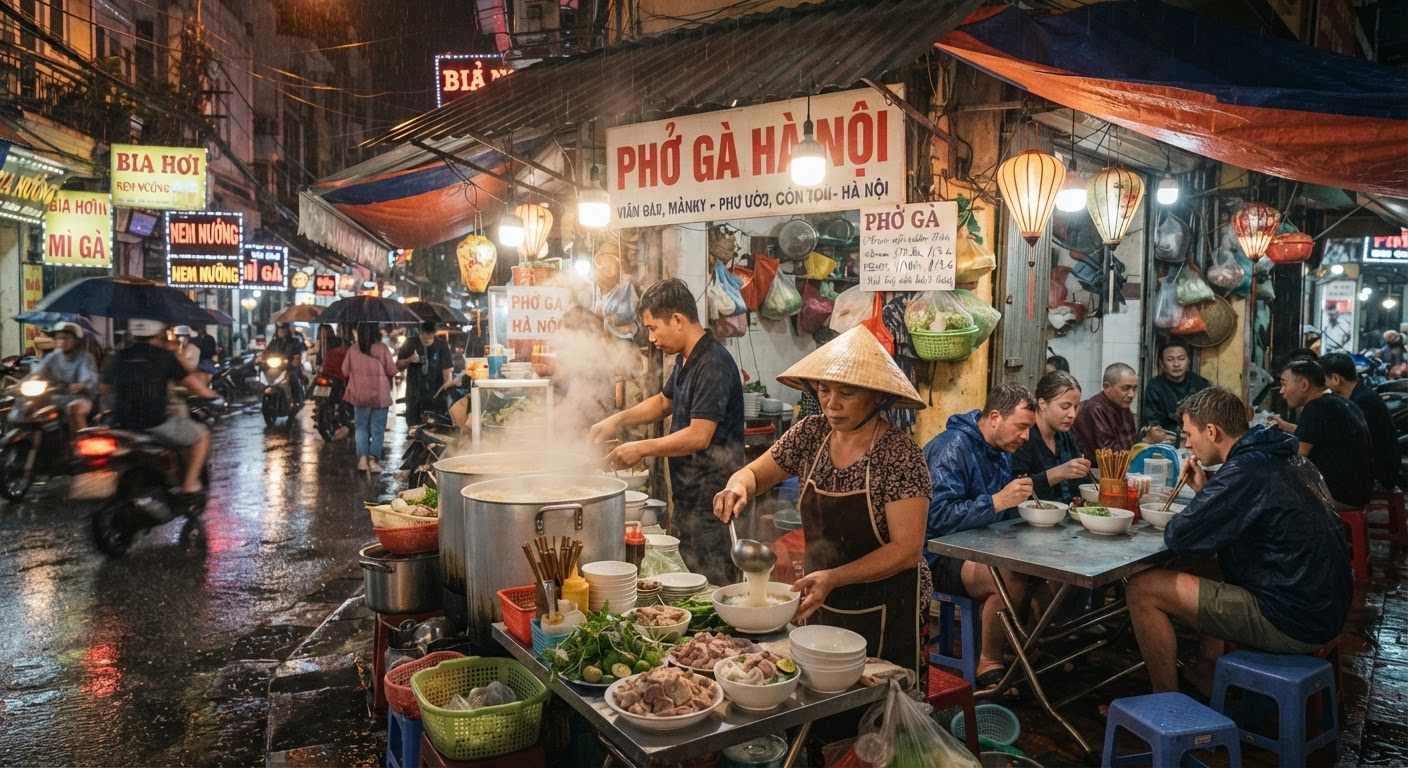

PosixPath('outputs/images/20261004-193822_a-photorealistic-vietnamese-street-food-.png')

In [10]:
gen_image(
    "A photorealistic Vietnamese street food stall at night, warm lights, light rain",
    aspect_ratio="16:9",              # 1:1, 3:4, 4:3, 16:9, 9:16
    # model="nano-banana-pro",        # best quality
    # model="nano-banana-2",
)

saved -> outputs/images/20261004-193906_mot-chu-meo-doi-non-la-phong-cach-tranh-.png


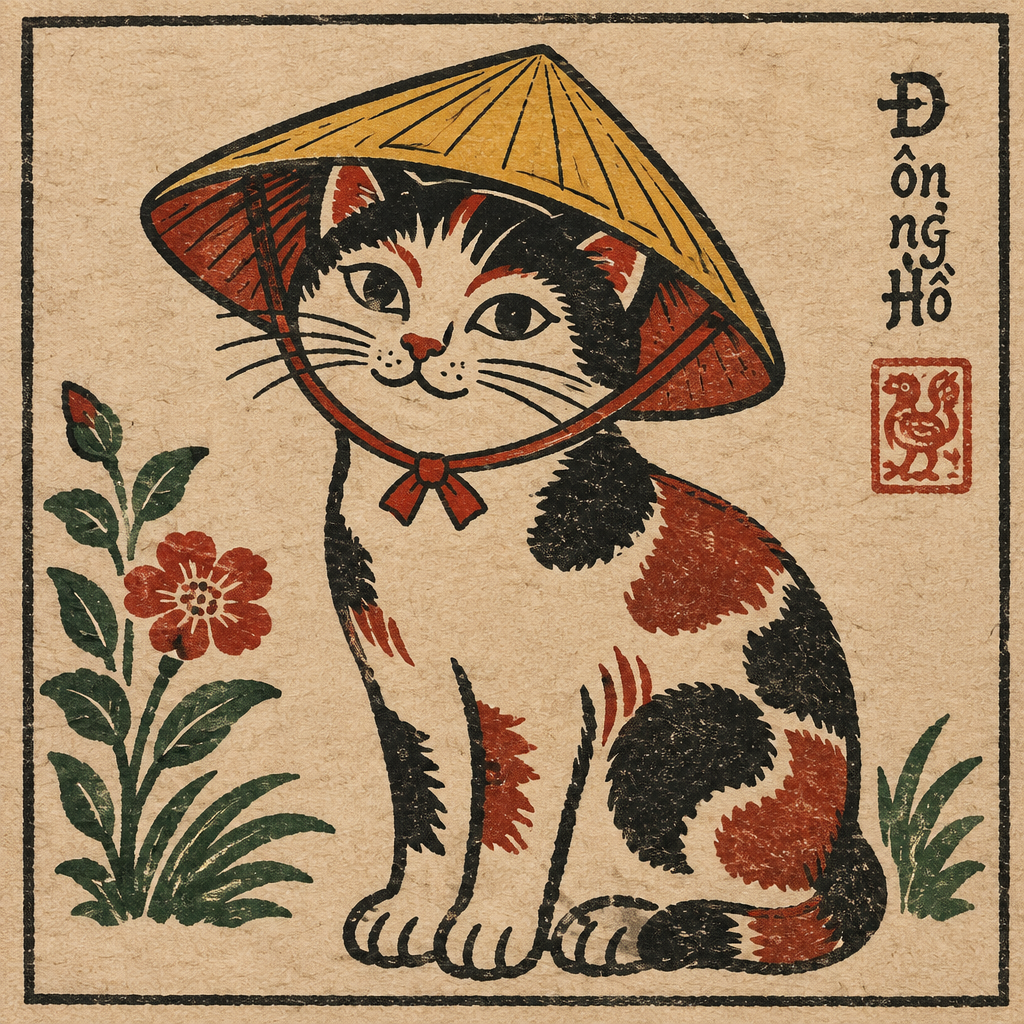

PosixPath('outputs/images/20261004-193906_mot-chu-meo-doi-non-la-phong-cach-tranh-.png')

In [11]:
# OpenAI image model (uses size + quality instead of aspect_ratio)
gen_image(
    "Một chú mèo đội nón lá, phong cách tranh Đông Hồ",
    model="gpt-image-2.5-flare",
    size="1024x1024",                 # 1024x1024, 1536x1024, 1024x1536
    quality="low",                    # low (cheapest), medium, high
)

### Text to speech

In [ ]:
gen_speech(
    "Xin chào các bạn, chào mừng đến với cuộc thi AI Thực Chiến.",
    voice="Zephyr",                   # see the Gemini voice list in Part 2
    # model="gemini-3.1-flash-tts-preview",
    # model="gpt-4o-mini-tts", voice="nova",     # OpenAI voice
)

### Speech to text

In [ ]:
# Point this at any mp3/wav (e.g. a file you just generated in outputs/audio/)
audio_files = sorted(Path("outputs/audio").glob("*.mp3"))
AUDIO_FILE = audio_files[-1] if audio_files else "speech.mp3"      # newest generated audio, or your own file
gen_transcript(AUDIO_FILE)

### Video (billed per second; defaults to cheapest model, 4 s)

In [ ]:
gen_video(
    "A cinematic shot of a hummingbird flying in slow motion",
    seconds=4,                        # 4, 6 or 8
    size="1280x720",                  # 1280x720, 1920x1080, 720x1280 (vertical), 1080x1920
    # model="veo-3.1-fast-generate-001",
    # input_image="outputs/images/your_image.png",   # image-to-video
)

**Video step by step** (use this if the notebook crashed or timed out - the job is already paid for).
Every started video id is in `outputs/history.jsonl`.

In [ ]:
VIDEO_ID = ""                          # paste an id here, e.g. "video_bGl0ZW..."
if VIDEO_ID:
    print(client.video_status(VIDEO_ID))                # processing / completed / failed
    # when completed:
    # _show(client.video_download(VIDEO_ID, prompt="my video"))

### Embeddings and moderation

In [ ]:
vecs = gen_embed(["Hà Nội là thủ đô của Việt Nam", "Thủ đô Việt Nam là thành phố nào?"])
gen_moderate("Chúc bạn một ngày tốt lành!")

### Spend

In [ ]:
spend()

## Part 5 - Smoke tests (run before competition day)

Run all cells below top to bottom. Each test records PASS / FAIL and the summary at the end shows which APIs work.
Use the `RUN` switches to skip costly ones. Estimated total with defaults: **about $0.30** (video $0.20 + search $0.03 + small stuff).

In [ ]:
TEST_MODELS = {
    "chat_gemini": "gemini-3.5-flash-lite",
    "chat_openai": "gpt-6-luna",
    "chat_deepseek": "deepseek-flash",
    "search_gemini": "gemini-3.5-flash-lite",
    "search_openai": "gpt-6-luna",
    "image": "nano-banana-2-lite",
    "image_chat": "nano-banana-2-lite",
    "image_openai": "gpt-image-2.5-flare",
    "tts": "gemini-2.5-flash-preview-tts",
    "stt": "gemini-3.5-transcribe-preview",
    "embedding": "text-multilingual-embedding-002",
    "moderation": "omni-moderation-latest",
    "video": "veo-3.1-lite-generate-001",
}

RUN = {
    "key_info": True,
    "chat_gemini": True, "chat_openai": True, "chat_deepseek": True,
    "search_gemini": True,          # ~ $0.03
    "search_openai": False,         # ~ $0.01+  (Responses API)
    "image": True, "image_chat": True,
    "image_openai": False,          # ~ $0.006
    "tts": True,
    "stt": True,                    # uses the audio from the tts test
    "embedding": True, "moderation": True,
    "video": True,                  # ~ $0.20 (4 s, lite)
    "image_to_video": False,        # another ~ $0.20; needs the image test first
}

RESULTS = []     # (name, status, seconds, cost, note)
STATE = {}       # pass files between tests (tts -> stt, image -> video)


def run_test(name, fn):
    if not RUN.get(name, True):
        print(f"--- {name}: SKIPPED")
        RESULTS.append((name, "SKIP", 0, None, ""))
        return
    print(f"=== {name}")
    client.last_cost = None
    t0 = time.time()
    try:
        note, status = fn(), "PASS"
    except Exception as e:                        # keep going on failure
        note, status = f"{type(e).__name__}: {e}", "FAIL"
        print("  ERROR:", note)
    dt = time.time() - t0
    RESULTS.append((name, status, dt, client.last_cost, str(note or "")[:70]))
    print(f"  -> {status} in {dt:.1f}s" + (f"  (cost ${client.last_cost:.5f})" if client.last_cost else ""))


def show_summary():
    print(f"{'test':<16}{'result':<8}{'time':>8}{'cost':>11}  note")
    for name, status, dt, cost, note in RESULTS:
        c = f"${cost:.5f}" if cost else "-"
        print(f"{name:<16}{status:<8}{dt:>7.1f}s{c:>11}  {note}")
    print(f"\nTotal cost seen by this client: ${client.total_cost:.4f}")

**5.1 Key info and spend**

In [ ]:
def t_key_info():
    info = client.key_info()["info"]
    print("alias:", info.get("key_alias"), "| key spend:", info.get("spend"), "| expires:", info.get("expires"))
    print("models:", info.get("models"))
    print("rpm per model:", (info.get("metadata") or {}).get("model_rpm_limit"))
    team = client.team_info(info["team_id"]).get("team_info", {})
    print(f"team spend {team.get('spend')} / budget {team.get('max_budget')}")
    return f"team spend {team.get('spend')} / {team.get('max_budget')}"

run_test("key_info", t_key_info)

**5.2 Text: Gemini, OpenAI, DeepSeek**

In [ ]:
def t_chat_gemini():
    out = client.ask("Hãy viết một câu giới thiệu về Việt Nam.", TEST_MODELS["chat_gemini"], system="Bạn là một trợ lý ảo.")
    print(out); assert out.strip(), "empty answer"; return out[:60]

def t_chat_openai():
    out = client.ask("Tóm tắt luật chơi cờ tướng trong 3 câu.", TEST_MODELS["chat_openai"],
                     reasoning_effort="low", max_tokens=4000)
    print(out); assert out.strip(), "empty answer (reasoning ate the token limit?)"; return out[:60]

def t_chat_deepseek():
    out = client.ask("Phân loại cảm xúc: 'Đồ ăn ngon, phục vụ chậm'", TEST_MODELS["chat_deepseek"],
                     thinking={"type": "disabled"})
    print(out); assert out.strip(), "empty answer"; return out[:60]

run_test("chat_gemini", t_chat_gemini)
run_test("chat_openai", t_chat_openai)
run_test("chat_deepseek", t_chat_deepseek)

**5.3 Web search: Gemini and OpenAI**

In [ ]:
def t_search_gemini():
    text, queries, sources = client.ask_with_search("Tỷ giá USD/VND hôm nay là bao nhiêu?", TEST_MODELS["search_gemini"])
    print(text); print("queries:", queries)
    for t, u in sources[:5]: print("-", t, u)
    return f"{len(queries)} queries, {len(sources)} sources"

def t_search_openai():
    resp = client.responses("Tỷ giá USD/VND hôm nay là bao nhiêu?", TEST_MODELS["search_openai"],
                            tools=[{"type": "web_search"}], max_output_tokens=4000)
    text = client.responses_text(resp)
    print(text); assert text.strip(), "empty answer"; return text[:60]

run_test("search_gemini", t_search_gemini)
run_test("search_openai", t_search_openai)

**5.4 Images: `/images/generations`, chat route, OpenAI image**

In [ ]:
def t_image():
    path, revised = client.generate_image(
        "a digital render of a massive skyscraper, modern, grand, epic with a beautiful sunset in the background",
        TEST_MODELS["image"], aspect_ratio="16:9")
    STATE["image_path"] = path
    _show(path); return path.name

def t_image_chat():
    path = client.generate_image_chat(
        "A majestic waterfall cascading down rugged cliffs under warm sunlight, with a rainbow in the mist.",
        TEST_MODELS["image_chat"])
    _show(path); return path.name

def t_image_openai():
    path, _ = client.generate_image("Một chú mèo đội nón lá, phong cách tranh Đông Hồ",
                                    TEST_MODELS["image_openai"], size="1024x1024", quality="low")
    _show(path); return path.name

run_test("image", t_image)
run_test("image_chat", t_image_chat)
run_test("image_openai", t_image_openai)

**5.5 Text-to-speech then speech-to-text (round trip)**

In [ ]:
TTS_TEXT = "Xin chào, đây là một thử nghiệm chuyển văn bản thành giọng nói qua AI Thực Chiến gateway."

def t_tts():
    path = client.text_to_speech(TTS_TEXT, TEST_MODELS["tts"], voice="Zephyr")
    STATE["audio_path"] = path
    _show(path); return path.name

def t_stt():
    audio = STATE.get("audio_path")
    assert audio, "run the tts test first (or set STATE['audio_path'] to your own audio file)"
    text = client.speech_to_text(audio, TEST_MODELS["stt"])
    print("original  :", TTS_TEXT); print("transcript:", text); return text[:60]

run_test("tts", t_tts)
run_test("stt", t_stt)

**5.6 Embeddings and moderation**

In [ ]:
def cosine(a, b):
    dot = sum(x * y for x, y in zip(a, b))
    return dot / ((sum(x * x for x in a) ** 0.5) * (sum(y * y for y in b) ** 0.5))

def t_embedding():
    texts = ["Hà Nội là thủ đô của Việt Nam", "Thủ đô Việt Nam là thành phố nào?", "Tôi thích ăn phở"]
    v = client.embed(texts, TEST_MODELS["embedding"])
    print("vectors:", len(v), "dims:", len(v[0]))
    print("similar pair  :", round(cosine(v[0], v[1]), 3))
    print("unrelated pair:", round(cosine(v[0], v[2]), 3))
    return f"{len(v[0])} dims"

def t_moderation():
    res = client.moderate("Chúc bạn một ngày tốt lành!", TEST_MODELS["moderation"])
    print("flagged:", res["flagged"]); return f"flagged={res['flagged']}"

run_test("embedding", t_embedding)
run_test("moderation", t_moderation)

**5.7 Video (start -> poll -> download), plus optional image-to-video**

In [ ]:
def t_video():
    path = client.generate_video("A cinematic shot of a hummingbird flying in slow motion",
                                 TEST_MODELS["video"], seconds=4, size="1280x720")
    _show(path); return path.name

def t_image_to_video():
    img = STATE.get("image_path")
    assert img, "run the image test first (or set STATE['image_path'] to your own PNG)"
    path = client.generate_video("The camera slowly pushes in as clouds drift across the sunset sky",
                                 TEST_MODELS["video"], seconds=4, input_image=img)
    _show(path); return path.name

run_test("video", t_video)
run_test("image_to_video", t_image_to_video)

**5.8 Summary**

In [ ]:
show_summary()
spend()

## Notes
- All files: `outputs/<type>/...`; the full log of prompts/models/costs/video IDs: `outputs/history.jsonl`.
- The notebook embeds generated images/videos when displayed. Use *Clear All Outputs* before sharing the notebook.
- Rate limits are per team, so many parallel requests can cause `429`; the client retries automatically.
- To use the client outside Jupyter, copy Part 1 (imports/config) and the `ThucChienClient` cell into a `.py` file.